# Polinomial Regression: Salary Prediction

A company wants to estimate the salary of employees based on their job level. The relationship between job level and salary is not linear because salaries increase gradually at lower levels but rise much faster for executive positions. As a result, a simple linear regression model does not accurately capture this trend.

To solve this problem, a Polynomial Regression model will be developed using historical employee data, where the input variable is the employee's Level (1–10) and the output variable is the corresponding Salary. The objective is to learn the nonlinear relationship between these variables so that the company can predict the expected salary for employees at intermediate or future job levels, such as Level 6.5.

The dataset contains the following variables:

Position: Employee job title.
Level: Numerical representation of the job position (independent variable).
Salary: Annual salary in dollars (dependent variable).

The goal is to train a polynomial regression model that accurately fits the data and provides reliable salary predictions based on an employee's job level.

### 0. Imports

In [1]:
# Installation of external libraries
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 2. CSV Data Reading

In [7]:
import numpy as np
dataset = pd.read_csv("datasets/Position_Salaries.csv") # DS DataFrame

In [8]:
X = dataset.iloc[:, 1:2].values   
y = dataset.iloc[:, 2].values
print("Data X: ", X)
print("Data y: ",y)

Data X:  [[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
Data y:  [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


### 3. Dataset Exploration

In [9]:
dataset 

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


### 4. Visualization of dataset

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

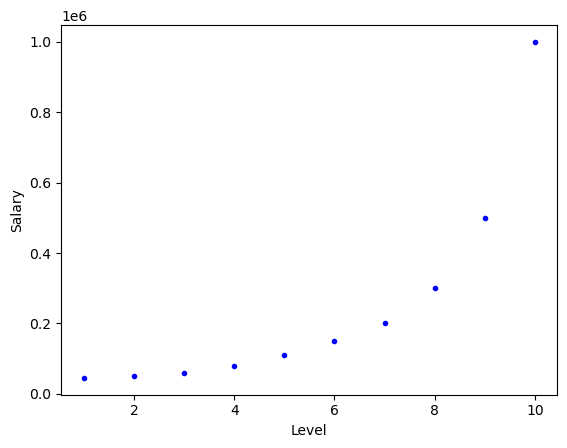

In [11]:
plt.plot(X, y, "b.")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

### 5. Fit the polynomial regression model on the training set

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [70]:
poly_Reg = PolynomialFeatures(degree = 5)
X_Poly = poly_Reg.fit_transform(X)
X_Poly 

array([[1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00],
       [1.0000e+00, 2.0000e+00, 4.0000e+00, 8.0000e+00, 1.6000e+01,
        3.2000e+01],
       [1.0000e+00, 3.0000e+00, 9.0000e+00, 2.7000e+01, 8.1000e+01,
        2.4300e+02],
       [1.0000e+00, 4.0000e+00, 1.6000e+01, 6.4000e+01, 2.5600e+02,
        1.0240e+03],
       [1.0000e+00, 5.0000e+00, 2.5000e+01, 1.2500e+02, 6.2500e+02,
        3.1250e+03],
       [1.0000e+00, 6.0000e+00, 3.6000e+01, 2.1600e+02, 1.2960e+03,
        7.7760e+03],
       [1.0000e+00, 7.0000e+00, 4.9000e+01, 3.4300e+02, 2.4010e+03,
        1.6807e+04],
       [1.0000e+00, 8.0000e+00, 6.4000e+01, 5.1200e+02, 4.0960e+03,
        3.2768e+04],
       [1.0000e+00, 9.0000e+00, 8.1000e+01, 7.2900e+02, 6.5610e+03,
        5.9049e+04],
       [1.0000e+00, 1.0000e+01, 1.0000e+02, 1.0000e+03, 1.0000e+04,
        1.0000e+05]])

In [71]:
poly_Reg_2 = LinearRegression()
poly_Reg_2.fit(X_Poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 6. Visualizing the Polynomial Regression Model Results

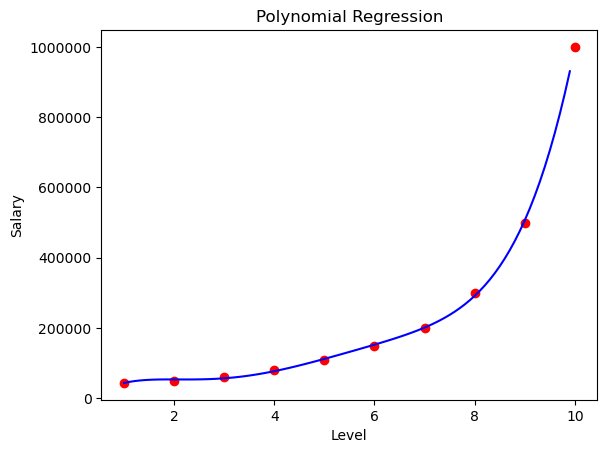

In [72]:
# Create a grid of points for a smoother curve
X_grid = np.arange(X.min(), X.max(), 0.1)
X_grid = X_grid.reshape(-1, 1)

# Plot the original data points
plt.scatter(X, y, color='red')

# Plot the polynomial regression curve
plt.plot(
    X_grid,
    poly_Reg_2.predict(poly_Reg.transform(X_grid)),
    color='blue'
)

# Add title and axis labels
plt.title('Polynomial Regression')
plt.xlabel('Level')
plt.ylabel('Salary')

# Display full values on the y-axis (disable scientific notation)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

### 7. Test Predictions

In [81]:
levels = np.array([1.5, 6.5, 7.5, 8.5]).reshape(-1, 1)
predicted_salaries = poly_Reg_2.predict(poly_Reg.transform(levels))

predicted_salaries

array([ 52717.63913188, 174878.07765158, 237446.00451607, 375829.49082119])

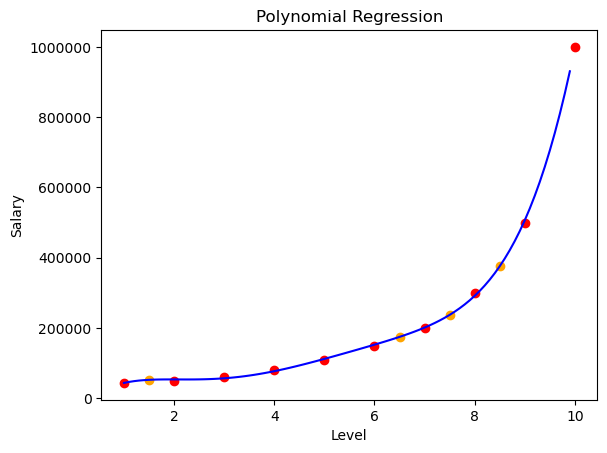

In [85]:
# Create a grid of points for a smoother curve
X_grid = np.arange(X.min(), X.max(), 0.1)
X_grid = X_grid.reshape(-1, 1)

# Plot the original data points
plt.scatter(X, y, color='red')
plt.scatter(levels, predicted_salaries, color='orange')

# Plot the polynomial regression curve
plt.plot(
    X_grid,
    poly_Reg_2.predict(poly_Reg.transform(X_grid)),
    color='blue'
)


# Add title and axis labels
plt.title('Polynomial Regression')
plt.xlabel('Level')
plt.ylabel('Salary')

# Display full values on the y-axis (disable scientific notation)
plt.ticklabel_format(style='plain', axis='y')

plt.show()